In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
import joblib
from datetime import datetime
from scipy import stats

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import mlflow
import mlflow.xgboost

In [2]:
conn = sqlite3.connect(r"J:\mlops_revisited\frieght_price_prediction\data\inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'", conn)

In [3]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables['name']:
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
    display(df)

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
vendor_df = pd.read_sql_query("select * from vendor_invoice", conn)
vendor_df.sample(5)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
847,6213,MHW LTD,2024-03-07,8933,2024-02-15,2024-04-01,4546,31105.97,139.98,None
964,98450,Serralles Usa LLC,2024-03-08,9107,2024-02-26,2024-04-19,168,2456.50,12.04,None
2990,9819,TREASURY WINE ESTATES,2024-07-22,11118,2024-07-08,2024-08-22,9082,51622.89,283.93,None
698,1189,BULLY BOY DISTILLERS,2024-03-01,8878,2024-02-11,2024-03-30,36,793.80,3.57,None
4526,3252,E & J GALLO WINERY,2024-11-05,12620,2024-10-16,2024-12-08,40794,278149.50,1390.75,Frank Delahunt


In [6]:
#check corelation
vendor_df[['Quantity', 'Dollars', 'Freight']].corr()

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


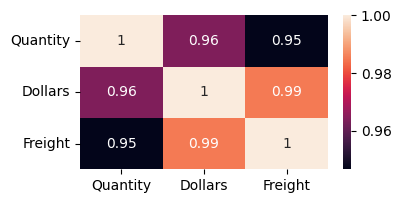

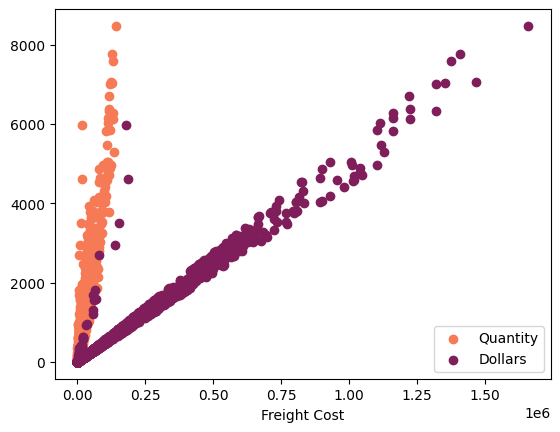

In [7]:
# Relationship between Quantity, Dollars and Freight
plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity', 'Dollars', 'Freight']].corr(), annot=True)
plt.show()

plt.scatter(vendor_df['Quantity'], vendor_df['Freight'], color='#f57a55')
plt.scatter(vendor_df['Dollars'], vendor_df['Freight'], color='#7f1e5a')
plt.legend(['Quantity','Dollars'])
plt.xlabel('Freight Cost')
plt.show()

In [8]:
vendor_df['freight_per_unit'] = vendor_df['Freight'] / vendor_df['Quantity']

In [9]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [10]:
f"{low_quantity} - {high_quantity}"

'83.0 - 5100.5'

In [11]:
print(vendor_df.loc[vendor_df['Quantity'] < low_quantity, 'freight_per_unit'].mean())
print(vendor_df.loc[vendor_df['Quantity'] > high_quantity, 'freight_per_unit'].mean())

0.09489854253138316
0.049077654690759046


In [12]:
# this means when its ordered in bulk qty then pay less 

### experiment

In [13]:
# Prepare features and target
X = vendor_df[['Quantity', 'Dollars']]
y = vendor_df['Freight']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Set MLflow tracking
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("freight_price_prediction")

<Experiment: artifact_location='mlflow-artifacts:/654049128111641531', creation_time=1774351685833, experiment_id='654049128111641531', last_update_time=1774351685833, lifecycle_stage='active', name='freight_price_prediction', tags={}>

#### Exp 1: Baseline

In [50]:
with mlflow.start_run():
    # Log preprocessing params
    mlflow.log_param('test_size', 0.2)
    mlflow.log_param('random_state', 42)
    mlflow.log_param('features', ['Quantity', 'Dollars'])
    
    # Initialize Random Forest Regressor
    rf_model = RandomForestRegressor(random_state=42)
    
    # Train the model
    rf_model.fit(X_train, y_train)
    
    #log model params
    mlflow.log_param('model', 'RandomForestRegressor')
    
    # Make predictions
    y_train_pred = rf_model.predict(X_train)
    y_test_pred = rf_model.predict(X_test)
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Log model parameters
    mlflow.log_param('n_estimators', rf_model.n_estimators)
    mlflow.log_param('max_depth', rf_model.max_depth)
    mlflow.log_param('min_samples_split', rf_model.min_samples_split)
    mlflow.log_param('min_samples_leaf', rf_model.min_samples_leaf)
    
    # Log metrics
    mlflow.log_metrics({
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'train_r2': train_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    })
    
    # Log the model
    mlflow.sklearn.log_model(rf_model, "random_forest_model")
    
    # log notebook
    import os
    notebook_path = r"J:\mlops_revisited\frieght_price_prediction\experiments\exp1.ipynb"
    os.system(f"jupyter nbconvert --to notebook --execute --inplace {notebook_path}")
    mlflow.log_artifact(notebook_path)
    
    
    #print results
    results = ({
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'train_r2': train_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    })
    
    print(results)

{'train_mae': 11.180793272714627, 'train_rmse': 58.52639324849567, 'train_r2': 0.9932476635492653, 'test_mae': 27.645808885229208, 'test_rmse': 138.62117343792318, 'test_r2': 0.9627905784240083}


#### Exp 2: Best Algorithm

In [18]:
# Set MLflow tracking
mlflow.set_experiment("freight_price_prediction_BestAlgorithm")

<Experiment: artifact_location='mlflow-artifacts:/161970139339449151', creation_time=1774351845151, experiment_id='161970139339449151', last_update_time=1774351845151, lifecycle_stage='active', name='freight_price_prediction_BestAlgorithm', tags={}>

In [22]:
import pandas as pd
import numpy as np
import sqlite3
import mlflow
import mlflow.sklearn
import time
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Import algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [23]:
# Dictionary of algorithms with their default parameters
algorithms = {
    # Linear Models
    'Linear Regression': {
        'model': LinearRegression(),
        'family': 'Linear',
        'needs_scaling': False
    },
    'Ridge Regression': {
        'model': Ridge(random_state=42),
        'family': 'Linear',
        'needs_scaling': True
    },
    'Lasso Regression': {
        'model': Lasso(random_state=42),
        'family': 'Linear',
        'needs_scaling': True
    },
    'Elastic Net': {
        'model': ElasticNet(random_state=42),
        'family': 'Linear',
        'needs_scaling': True
    },
    
    # Tree-based Models
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'family': 'Tree',
        'needs_scaling': False
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'family': 'Tree',
        'needs_scaling': False
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'family': 'Tree',
        'needs_scaling': False
    },
    'AdaBoost': {
        'model': AdaBoostRegressor(random_state=42),
        'family': 'Tree',
        'needs_scaling': False
    },
    
    # Advanced Tree Models
    'XGBoost': {
        'model': XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        'family': 'Tree',
        'needs_scaling': False
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        'family': 'Tree',
        'needs_scaling': False
    },
    
    # Other Models
    'KNN Regressor': {
        'model': KNeighborsRegressor(n_jobs=-1),
        'family': 'Distance',
        'needs_scaling': True
    },
    'SVR': {
        'model': SVR(),
        'family': 'Kernel',
        'needs_scaling': True
    }
}

In [24]:
# Store results list before parent run
results = []

with mlflow.start_run(run_name='all_runs') as parent_run:
    # Log parent-level metadata
    mlflow.log_param('experiment_level', 'Level3_Algorithm_Selection')
    mlflow.log_param('total_algorithms_tested', len(algorithms))
    mlflow.log_param('test_size', 0.2)
    mlflow.log_param('random_state', 42)
    mlflow.log_param('features', ['Quantity', 'Dollars'])
    mlflow.log_param('timestamp', datetime.now().isoformat())
    
    # Loop through algorithms (child runs)
    for algo_name, algo_config in algorithms.items():
        print(f"\n{'='*50}")
        print(f"Testing: {algo_name}")
        print(f"Family: {algo_config['family']}")
        print(f"{'='*50}")
        
        # Create child run under parent
        with mlflow.start_run(run_name=f"{algo_name}", nested=True) as child_run:
            # Log algorithm metadata
            mlflow.log_param('algorithm', algo_name)
            mlflow.log_param('algorithm_family', algo_config['family'])
            mlflow.log_param('needs_scaling', algo_config['needs_scaling'])
            
            # Scale features if needed
            X_train_scaled = X_train.copy()
            X_test_scaled = X_test.copy()
            scaler = None
            
            if algo_config['needs_scaling']:
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)
                mlflow.log_param('scaling_applied', 'StandardScaler')
            
            # Train model
            model = algo_config['model']
            start_time = time.time()
            model.fit(X_train_scaled, y_train)
            train_time = time.time() - start_time
            
            # Make predictions
            start_time = time.time()
            y_train_pred = model.predict(X_train_scaled)
            y_test_pred = model.predict(X_test_scaled)
            predict_time = time.time() - start_time
            
            # Calculate metrics
            train_mae = mean_absolute_error(y_train, y_train_pred)
            train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
            train_r2 = r2_score(y_train, y_train_pred)
            
            test_mae = mean_absolute_error(y_test, y_test_pred)
            test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
            test_r2 = r2_score(y_test, y_test_pred)
            
            # Cross-validation scores
            cv_scores = cross_val_score(
                model, X_train_scaled, y_train, 
                cv=5, scoring='r2', n_jobs=-1
            )
            cv_r2_mean = cv_scores.mean()
            cv_r2_std = cv_scores.std()
            
            # Log model parameters
            for key, value in model.get_params().items():
                if isinstance(value, (int, float, str, bool)) and not callable(value):
                    try:
                        mlflow.log_param(f"param_{key}", value)
                    except:
                        pass
            
            # Log metrics
            mlflow.log_metrics({
                'train_mae': train_mae,
                'train_rmse': train_rmse,
                'train_r2': train_r2,
                'test_mae': test_mae,
                'test_rmse': test_rmse,
                'test_r2': test_r2,
                'cv_r2_mean': cv_r2_mean,
                'cv_r2_std': cv_r2_std,
                'train_time_seconds': train_time,
                'predict_time_seconds': predict_time,
                'overfitting_gap': train_r2 - test_r2
            })
            
            # Log model
            mlflow.sklearn.log_model(model, f"{algo_name.lower().replace(' ', '_')}_model")
            
            # Store results
            results.append({
                'Algorithm': algo_name,
                'Family': algo_config['family'],
                'Train_R2': train_r2,
                'Test_R2': test_r2,
                'Test_MAE': test_mae,
                'Test_RMSE': test_rmse,
                'CV_R2_Mean': cv_r2_mean,
                'CV_R2_Std': cv_r2_std,
                'Train_Time': train_time,
                'Predict_Time': predict_time,
                'Overfitting_Gap': train_r2 - test_r2,
                'Needs_Scaling': algo_config['needs_scaling']
            })
            
            # Print results
            print(f"✓ Training Time: {train_time:.2f} seconds")
            print(f"✓ Test R²: {test_r2:.4f}")
            print(f"✓ Test MAE: ${test_mae:.2f}")
            print(f"✓ CV R²: {cv_r2_mean:.4f} (±{cv_r2_std:.4f})")
            
            if train_r2 - test_r2 > 0.05:
                print(f"⚠️  Warning: Possible overfitting (gap: {train_r2 - test_r2:.4f})")
    
    # After all child runs, log parent-level summary
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Test_R2', ascending=False)
    
    # Log parent-level summary
    mlflow.log_text(results_df.to_string(), "algorithm_comparison_summary.txt")
    
    # Log best algorithm info
    best_algo = results_df.iloc[0]
    mlflow.log_param('best_algorithm', best_algo['Algorithm'])
    mlflow.log_metric('best_test_r2', best_algo['Test_R2'])
    mlflow.log_metric('best_test_mae', best_algo['Test_MAE'])
    
    print("\n" + "="*80)
    print("PARENT RUN SUMMARY")
    print("="*80)
    print(f"Parent Run ID: {parent_run.info.run_id}")
    print(f"Best Algorithm: {best_algo['Algorithm']}")
    print(f"Best Test R²: {best_algo['Test_R2']:.4f}")
    print(f"Best Test MAE: ${best_algo['Test_MAE']:.2f}")
    print("\nTop 3 Algorithms:")
    for i, row in results_df.head(3).iterrows():
        print(f"  {i+1}. {row['Algorithm']}: R² = {row['Test_R2']:.4f}, MAE = ${row['Test_MAE']:.2f}")


Testing: Linear Regression
Family: Linear
✓ Training Time: 0.26 seconds
✓ Test R²: 0.9700
✓ Test MAE: $24.46
✓ CV R²: 0.9695 (±0.0236)

Testing: Ridge Regression
Family: Linear
✓ Training Time: 0.29 seconds
✓ Test R²: 0.9700
✓ Test MAE: $24.46
✓ CV R²: 0.9695 (±0.0236)

Testing: Lasso Regression
Family: Linear
✓ Training Time: 0.03 seconds
✓ Test R²: 0.9699
✓ Test MAE: $24.33
✓ CV R²: 0.9695 (±0.0235)

Testing: Elastic Net
Family: Linear
✓ Training Time: 0.01 seconds
✓ Test R²: 0.9120
✓ Test MAE: $93.91
✓ CV R²: 0.9120 (±0.0250)

Testing: Decision Tree
Family: Tree
✓ Training Time: 0.17 seconds
✓ Test R²: 0.9355
✓ Test MAE: $33.87
✓ CV R²: 0.9178 (±0.0556)
⚠️  Warning: Possible overfitting (gap: 0.0645)

Testing: Random Forest
Family: Tree
✓ Training Time: 3.05 seconds
✓ Test R²: 0.9628
✓ Test MAE: $27.65
✓ CV R²: 0.9500 (±0.0288)

Testing: Gradient Boosting
Family: Tree
✓ Training Time: 1.64 seconds
✓ Test R²: 0.9657
✓ Test MAE: $24.59
✓ CV R²: 0.9520 (±0.0271)

Testing: AdaBoost
Fam

#### exp3: XGBoost Hyper parameter tuning

In [25]:
# Set MLflow tracking
mlflow.set_experiment("freight_price_prediction_XGBoost_HyperParameterTuning")

2026/03/24 17:26:21 INFO mlflow.tracking.fluent: Experiment with name 'freight_price_prediction_XGBoost_HyperParameterTuning' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/955111309604387626', creation_time=1774353381614, experiment_id='955111309604387626', last_update_time=1774353381614, lifecycle_stage='active', name='freight_price_prediction_XGBoost_HyperParameterTuning', tags={}>

In [30]:
import mlflow
import mlflow.xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from datetime import datetime

# OPTIMIZED PARAMETER GRID - Only most important parameters
param_grid = {
    'max_depth': [3, 5, 7],           
    'learning_rate': [0.05, 0.1, 0.2], 
    'n_estimators': [200, 500],        
    'subsample': [0.8, 1.0],           
    'colsample_bytree': [0.8, 1.0]     
}

# Calculate total combinations
total_combinations = 1
for key, values in param_grid.items():
    total_combinations *= len(values)

print(f"Total hyperparameter combinations: {total_combinations}")

# ONLY ONE OUTER RUN: Best_XGBoost
with mlflow.start_run(run_name="Best_XGBoost") as outer_run:    
    print("=" * 60)
    print(f"OUTER RUN: {outer_run.info.run_name}")
    print("=" * 60)
    print(f"Parameter grid size: {total_combinations} combinations")
    print(f"CV folds: 5")
    print(f"Total fits: {total_combinations * 5}")
    
    # Initialize GridSearchCV
    grid_search = GridSearchCV(
        XGBRegressor(random_state=42, n_jobs=-1),
        param_grid=param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=2,
        return_train_score=True
    )
    
    # Fit the grid search
    print("\nStarting Grid Search...")
    grid_search.fit(X_train, y_train)
    

    # LOG BEST PARAMETERS IN OUTER RUN
    print("\n" + "=" * 60)
    print("OUTER RUN: Logging Best Parameters")
    print("=" * 60)
    
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("best_cv_r2", grid_search.best_score_)
    mlflow.log_metric("best_cv_r2_std", grid_search.cv_results_['std_test_score'][grid_search.best_index_])
    mlflow.log_param("total_combinations_tested", total_combinations)
    
    # Save best params
    with open("best_params.json", "w") as f:
        json.dump(grid_search.best_params_, f, indent=2)
    mlflow.log_artifact("best_params.json")
    

    # EVALUATE BEST MODEL ON TEST SET
    y_pred_best = grid_search.best_estimator_.predict(X_test)
    test_r2 = r2_score(y_test, y_pred_best)
    test_mae = mean_absolute_error(y_test, y_pred_best)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
    
    mlflow.log_metric("test_r2", test_r2)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("test_rmse", test_rmse)
    

    # LOG BEST MODEL IN OUTER RUN
    mlflow.xgboost.log_model(
        grid_search.best_estimator_, 
        "model",
        registered_model_name="xgboost_best_model"
    )
    

    # CREATE AND LOG VISUALIZATIONS
    
    # Feature Importance Plot
    if hasattr(grid_search.best_estimator_, 'feature_importances_'):
        importances = grid_search.best_estimator_.feature_importances_
        feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(len(importances))]
        
        fig, ax = plt.subplots(figsize=(10, 8))
        indices = np.argsort(importances)[-20:]
        ax.barh(range(len(indices)), importances[indices])
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i] for i in indices])
        ax.set_xlabel('Feature Importance')
        ax.set_title('Top 20 Feature Importances')
        plt.tight_layout()
        plt.savefig('feature_importance.png')
        mlflow.log_artifact('feature_importance.png')
        plt.close()
    
    # Actual vs Predicted Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(y_test, y_pred_best, alpha=0.5)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual Values')
    axes[0].set_ylabel('Predicted Values')
    axes[0].set_title(f'Actual vs Predicted\nR² = {test_r2:.4f}')
    
    residuals = y_test - y_pred_best
    axes[1].scatter(y_pred_best, residuals, alpha=0.5)
    axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted Values')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'Residual Plot\nMAE = ${test_mae:.2f}')
    
    plt.tight_layout()
    plt.savefig('predictions_plot.png')
    mlflow.log_artifact('predictions_plot.png')
    plt.close()
    
    # Print best results
    print(f"\n{'=' * 60}")
    print(f"BEST XGBOOST RESULTS")
    print(f"{'=' * 60}")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV R²: {grid_search.best_score_:.4f} (±{grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.4f})")
    print(f"Test R²: {test_r2:.4f}")
    print(f"Test MAE: ${test_mae:.2f}")
    

    # NESTED RUNS: All Hyperparameter Combinations

    print("\n" + "=" * 60)
    print("NESTED RUNS: Logging All Parameter Combinations")
    print("=" * 60)
    
    print(f"Total combinations to log: {total_combinations}")
    
    # Loop through all combinations and create nested runs
    for i, (params, mean_score, std_score) in enumerate(zip(
        grid_search.cv_results_['params'],
        grid_search.cv_results_['mean_test_score'],
        grid_search.cv_results_['std_test_score']
    )):
        # Create NESTED run INSIDE the outer run
        with mlflow.start_run(run_name=f"Param_Combination_{i}", nested=True):
            
            # Log all parameters for this combination
            mlflow.log_params(params)
            
            # Log CV metrics
            mlflow.log_metric("cv_mean_r2", mean_score)
            mlflow.log_metric("cv_std_r2", std_score)
            mlflow.log_metric("cv_rank", grid_search.cv_results_['rank_test_score'][i])
            
            # Log train score if available
            if 'mean_train_score' in grid_search.cv_results_:
                train_score = grid_search.cv_results_['mean_train_score'][i]
                mlflow.log_metric("cv_mean_train_r2", train_score)
                overfit_gap = train_score - mean_score
                mlflow.log_metric("overfit_gap", overfit_gap)
            
            # Mark the best combination
            if i == grid_search.best_index_:
                mlflow.set_tag("is_best_combination", "true")
                mlflow.log_text("⭐ BEST COMBINATION ⭐", "best_combination.txt")
            
            # Progress indicator
            if (i + 1) % 20 == 0:
                print(f"Logged {i + 1}/{total_combinations} combinations...")
    

    # LOG ADDITIONAL ARTIFACTS IN OUTER RUN

    print("\n" + "=" * 60)
    print("OUTER RUN: Logging Additional Artifacts")
    print("=" * 60)
    
    # Save grid search results
    results_df = pd.DataFrame(grid_search.cv_results_)
    results_df.to_csv('grid_search_results.csv', index=False)
    mlflow.log_artifact('grid_search_results.csv')
    
    # Save test predictions
    predictions_df = pd.DataFrame({
        'actual': y_test,
        'predicted': y_pred_best,
        'residual': residuals
    })
    predictions_df.to_csv('test_predictions.csv', index=False)
    mlflow.log_artifact('test_predictions.csv')
    
    # Save summary
    summary = {
        'best_params': grid_search.best_params_,
        'best_cv_r2': float(grid_search.best_score_),
        'test_r2': float(test_r2),
        'test_mae': float(test_mae),
        'test_rmse': float(test_rmse),
        'total_combinations': total_combinations,
        'n_train_samples': len(X_train),
        'n_test_samples': len(X_test),
        'n_features': X_train.shape[1],
        'timestamp': datetime.now().isoformat()
    }
    
    with open('summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    mlflow.log_artifact('summary.json')
    
    # Log dataset info
    mlflow.log_param("n_train_samples", len(X_train))
    mlflow.log_param("n_test_samples", len(X_test))
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("timestamp", datetime.now().isoformat())
    
    print("\n" + "=" * 60)
    print(f"RUN COMPLETED")
    print(f"Outer Run: Best_XGBoost")
    print(f"Run ID: {mlflow.active_run().info.run_id}")
    print(f"Total nested runs: {total_combinations}")
    print(f"Best Test R²: {test_r2:.4f}")
    print(f"Best Test MAE: ${test_mae:.2f}")
    print("=" * 60)
    
    # Print top 5 combinations
    print("\n" + "=" * 60)
    print("TOP 5 PARAMETER COMBINATIONS")
    print("=" * 60)
    top_indices = np.argsort(grid_search.cv_results_['mean_test_score'])[-5:][::-1]
    for rank, idx in enumerate(top_indices, 1):
        params = grid_search.cv_results_['params'][idx]
        score = grid_search.cv_results_['mean_test_score'][idx]
        print(f"\n{rank}. CV R²: {score:.4f}")
        for key, value in params.items():
            print(f"   {key}: {value}")

Total hyperparameter combinations: 72
OUTER RUN: Best_XGBoost
Parameter grid size: 72 combinations
CV folds: 5
Total fits: 360

Starting Grid Search...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

OUTER RUN: Logging Best Parameters


j:\mlops_revisited\frieght_price_prediction\venv\lib\site-packages\xgboost\sklearn.py:1116: UserWarning: [17:48:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)
Successfully registered model 'xgboost_best_model'.
2026/03/24 17:49:17 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: xgboost_best_model, version 1
Created version '1' of model 'xgboost_best_model'.



BEST XGBOOST RESULTS
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV R²: 0.9606 (±0.0220)
Test R²: 0.9550
Test MAE: $25.94

NESTED RUNS: Logging All Parameter Combinations
Total combinations to log: 72
Logged 20/72 combinations...
Logged 40/72 combinations...
Logged 60/72 combinations...

OUTER RUN: Logging Additional Artifacts

RUN COMPLETED
Outer Run: Best_XGBoost
Run ID: 36781d25f4cb4dee93119f0b396bf37d
Total nested runs: 72
Best Test R²: 0.9550
Best Test MAE: $25.94

TOP 5 PARAMETER COMBINATIONS

1. CV R²: 0.9606
   colsample_bytree: 1.0
   learning_rate: 0.05
   max_depth: 3
   n_estimators: 200
   subsample: 0.8

2. CV R²: 0.9605
   colsample_bytree: 1.0
   learning_rate: 0.05
   max_depth: 3
   n_estimators: 200
   subsample: 1.0

3. CV R²: 0.9600
   colsample_bytree: 1.0
   learning_rate: 0.1
   max_depth: 3
   n_estimators: 200
   subsample: 0.8

4. CV R²: 0.9596
   colsample_bytree: 1.0
   learn

In [8]:
vendor_df.sample(5)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
3934,1485,CASTLE BRANDS CORP.,2024-10-02,12127,2024-09-16,2024-10-27,1371,20055.24,102.28,None
1096,4466,AMERICAN VINTAGE BEVERAGE,2024-03-23,9244,2024-03-08,2024-04-21,161,1510.69,6.95,None
3513,3664,WILLIAM GRANT & SONS INC,2024-08-28,11539,2024-08-07,2024-09-23,7511,154239.69,786.62,None
2428,1485,CASTLE BRANDS CORP.,2024-06-25,10615,2024-06-10,2024-07-26,1901,28397.31,139.15,None
2686,98450,Serralles Usa LLC,2024-07-06,10807,2024-06-23,2024-08-10,140,2007.04,9.83,None


#### Example 4: Feature Engineering

In [14]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("freight_price_prediction_advanced_features")

2026/03/25 22:38:25 INFO mlflow.tracking.fluent: Experiment with name 'freight_price_prediction_advanced_features' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/108578000703691526', creation_time=1774458505499, experiment_id='108578000703691526', last_update_time=1774458505499, lifecycle_stage='active', name='freight_price_prediction_advanced_features', tags={}>

In [15]:
vendor_df = pd.read_sql_query("select * from vendor_invoice", conn)
purchase_prices_df = pd.read_sql_query("select * from purchase_prices", conn)
purchases_df = pd.read_sql_query("select * from purchases", conn)
begin_inventory_df = pd.read_sql_query("select * from begin_inventory", conn)
end_inventory_df = pd.read_sql_query("select * from end_inventory", conn)

In [16]:
def create_advanced_features(vendor_df, purchase_prices_df, purchases_df, 
                            begin_inventory_df, end_inventory_df):
    """
    Create comprehensive features from all available tables
    """
    df = vendor_df.copy()
    
    # Print column information for debugging
    print("vendor_df columns:", df.columns.tolist())
    if purchases_df is not None:
        print("purchases_df columns:", purchases_df.columns.tolist())
    if purchase_prices_df is not None:
        print("purchase_prices_df columns:", purchase_prices_df.columns.tolist())
    if begin_inventory_df is not None:
        print("begin_inventory_df columns:", begin_inventory_df.columns.tolist())
    if end_inventory_df is not None:
        print("end_inventory_df columns:", end_inventory_df.columns.tolist())
    
    # ---------- 1. Time-Based Features ----------
    print("  • Creating time-based features...")
    
    # Convert date columns
    if 'InvoiceDate' in df.columns:
        df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
        df['invoice_month'] = df['InvoiceDate'].dt.month
        df['invoice_quarter'] = df['InvoiceDate'].dt.quarter
        df['invoice_year'] = df['InvoiceDate'].dt.year
        df['invoice_day_of_week'] = df['InvoiceDate'].dt.dayofweek
        df['invoice_weekend'] = (df['invoice_day_of_week'] >= 5).astype(int)
        df['is_holiday_season'] = df['invoice_month'].isin([11, 12]).astype(int)
        df['is_summer'] = df['invoice_month'].isin([6, 7, 8]).astype(int)
        df['is_q4'] = (df['invoice_quarter'] == 4).astype(int)
    
    if 'PayDate' in df.columns:
        df['PayDate'] = pd.to_datetime(df['PayDate'], errors='coerce')
    
    if 'InvoiceDate' in df.columns and 'PayDate' in df.columns:
        df['days_to_pay'] = (df['PayDate'] - df['InvoiceDate']).dt.days
        df['payment_efficiency'] = 1 / (df['days_to_pay'].clip(lower=1))
    
    # ---------- 2. Size & Volume Features ----------
    print("  • Creating size and volume features...")
    
    if 'Size' in df.columns:
        # Extract numeric volume from Size (e.g., "750ml" -> 750)
        df['volume_ml'] = df['Size'].astype(str).str.extract('(\d+\.?\d*)').astype(float)
        df['volume_liters'] = df['volume_ml'] / 1000
        
        # Size categories (only if we have valid volume data)
        if df['volume_ml'].notna().any():
            try:
                df['size_category'] = pd.cut(df['volume_ml'], 
                                             bins=[0, 500, 750, 1000, 1750, np.inf],
                                             labels=['mini', 'standard', 'large', 'xl', 'bulk'])
            except:
                print("  ⚠️ Could not create size_category")
    
    # ---------- 3. Price Features from Purchase Prices ----------
    print("  • Creating price features...")
    
    if purchase_prices_df is not None and len(purchase_prices_df) > 0:
        pp = purchase_prices_df.copy()
        
        # Check what columns are available
        if 'Brand' in df.columns and 'Size' in df.columns:
            # Merge on Brand and Size if available
            if 'Brand' in pp.columns and 'Size' in pp.columns:
                # Get purchase price
                if 'PurchasePrice' in pp.columns:
                    df = df.merge(pp[['Brand', 'Size', 'PurchasePrice']], on=['Brand', 'Size'], how='left')
                
                # Get retail price
                if 'Price' in pp.columns:
                    df = df.merge(pp[['Brand', 'Size', 'Price']], on=['Brand', 'Size'], how='left', suffixes=('', '_retail'))
                    
                # Calculate margin if both prices exist
                if 'PurchasePrice' in df.columns and 'Price' in df.columns:
                    df['margin_per_unit'] = df['Price'] - df['PurchasePrice']
                    df['margin_percentage'] = (df['margin_per_unit'] / df['Price'] * 100).clip(lower=0, upper=100)
    
    # ---------- 4. Vendor Performance Features ----------
    print("  • Creating vendor performance features...")
    
    if purchases_df is not None and len(purchases_df) > 0:
        purchases = purchases_df.copy()
        
        # Check if VendorNumber exists
        if 'VendorNumber' in purchases.columns:
            # Dynamically build aggregation dictionary based on available columns
            agg_dict = {}
            
            if 'Dollars' in purchases.columns:
                agg_dict['Dollars'] = ['sum', 'mean', 'count']
            if 'Quantity' in purchases.columns:
                agg_dict['Quantity'] = ['sum', 'mean']
            # Only add Freight if it exists
            if 'Freight' in purchases.columns:
                agg_dict['Freight'] = ['sum', 'mean']
            
            if agg_dict:
                vendor_stats = purchases.groupby('VendorNumber').agg(agg_dict).reset_index()
                
                # Flatten column names dynamically
                new_columns = ['VendorNumber']
                for col in agg_dict.keys():
                    for agg in agg_dict[col]:
                        new_columns.append(f'vendor_{col}_{agg}')
                
                vendor_stats.columns = new_columns
                
                # Merge with main dataframe
                if 'VendorNumber' in df.columns:
                    df = df.merge(vendor_stats, on='VendorNumber', how='left')
            else:
                print("  ⚠️ No valid columns for vendor aggregation")
    
    # ---------- 5. Inventory Features ----------
    print("  • Creating inventory features...")
    
    # Begin inventory
    if begin_inventory_df is not None and len(begin_inventory_df) > 0:
        begin_inv = begin_inventory_df.copy()
        
        if 'onHand' in begin_inv.columns:
            # Aggregate by Brand and Size if available
            if 'Brand' in begin_inv.columns and 'Size' in begin_inv.columns and 'Brand' in df.columns and 'Size' in df.columns:
                inv_start = begin_inv.groupby(['Brand', 'Size'])['onHand'].mean().reset_index()
                inv_start.columns = ['Brand', 'Size', 'avg_begin_inventory']
                df = df.merge(inv_start, on=['Brand', 'Size'], how='left')
            else:
                # Just overall average
                avg_begin_inv = begin_inv['onHand'].mean()
                df['avg_begin_inventory'] = avg_begin_inv
    
    # End inventory
    if end_inventory_df is not None and len(end_inventory_df) > 0:
        end_inv = end_inventory_df.copy()
        
        if 'onHand' in end_inv.columns:
            # Aggregate by Brand and Size if available
            if 'Brand' in end_inv.columns and 'Size' in end_inv.columns and 'Brand' in df.columns and 'Size' in df.columns:
                inv_end = end_inv.groupby(['Brand', 'Size'])['onHand'].mean().reset_index()
                inv_end.columns = ['Brand', 'Size', 'avg_end_inventory']
                df = df.merge(inv_end, on=['Brand', 'Size'], how='left')
            else:
                # Just overall average
                avg_end_inv = end_inv['onHand'].mean()
                df['avg_end_inventory'] = avg_end_inv
        
        # Calculate inventory turnover if we have quantity sold
        if 'Quantity' in df.columns and 'avg_begin_inventory' in df.columns and 'avg_end_inventory' in df.columns:
            df['avg_inventory'] = (df['avg_begin_inventory'] + df['avg_end_inventory']) / 2
            df['inventory_turnover'] = df['Quantity'] / df['avg_inventory'].clip(lower=1)
    
    # ---------- 6. Transaction-Level Features ----------
    print("  • Creating transaction features...")
    
    if 'Quantity' in df.columns and 'Dollars' in df.columns:
        df['avg_unit_price'] = df['Dollars'] / df['Quantity'].clip(lower=1)
        df['log_quantity'] = np.log1p(df['Quantity'])
        df['log_dollars'] = np.log1p(df['Dollars'])
    
    if 'Freight' in df.columns:
        df['freight_per_unit'] = df['Freight'] / df['Quantity'].clip(lower=1)
        df['freight_per_dollar'] = df['Freight'] / df['Dollars'].clip(lower=1)
        df['log_freight'] = np.log1p(df['Freight'])
    
    # ---------- 7. Categorical Features ----------
    print("  • Creating categorical features...")
    
    # Brand popularity
    if 'Brand' in df.columns:
        brand_freq = df['Brand'].value_counts().to_dict()
        df['brand_frequency'] = df['Brand'].map(brand_freq)
    
    # Store features if Store column exists
    if 'Store' in df.columns and 'Freight' in df.columns:
        store_avg_freight = df.groupby('Store')['Freight'].mean().to_dict()
        df['store_avg_freight'] = df['Store'].map(store_avg_freight)
    
    # ---------- 8. Business Logic Features ----------
    print("  • Creating business logic features...")
    
    # Bulk order indicator
    if 'Quantity' in df.columns:
        df['is_bulk_order'] = (df['Quantity'] > df['Quantity'].quantile(0.75)).astype(int)
    
    # High value order
    if 'Dollars' in df.columns:
        df['is_high_value'] = (df['Dollars'] > df['Dollars'].quantile(0.9)).astype(int)
    
    # ---------- 9. Handle Missing Values ----------
    print("  • Handling missing values...")
    
    # Fill numeric columns with median
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    
    # Create missing indicators for key columns
    for col in ['Size', 'Brand', 'Classification']:
        if col in df.columns:
            df[f'missing_{col}'] = df[col].isna().astype(int)
    
    print(f"Feature engineering complete! Total features: {len(df.columns)}")
    
    return df

# Create features
df_engineered = create_advanced_features(
    vendor_df, purchase_prices_df, purchases_df,
    begin_inventory_df, end_inventory_df
)

vendor_df columns: ['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate', 'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval']
purchases_df columns: ['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber', 'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification']
purchase_prices_df columns: ['Brand', 'Description', 'Price', 'Size', 'Volume', 'Classification', 'PurchasePrice', 'VendorNumber', 'VendorName']
begin_inventory_df columns: ['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'startDate']
end_inventory_df columns: ['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'endDate']
  • Creating time-based features...
  • Creating size and volume features...
  • Creating price features...
  • Creating vendor performance features...
  • Creating inventory features...
  • Creating transaction features...
  • Creat

In [17]:
# Define target
target = 'Freight'

# Define feature categories to use
feature_groups = {
    'core': ['Quantity', 'Dollars', 'PurchasePrice', 'avg_unit_price'],
    'time': ['days_to_receive', 'days_to_receive_log', 'days_to_pay', 'days_po_to_invoice',
             'invoice_month', 'invoice_quarter', 'invoice_weekend', 'is_holiday_season',
             'is_summer', 'is_q4', 'payment_efficiency'],
    'volume': ['volume_ml', 'volume_liters', 'total_volume_ml', 'total_volume_liters'],
    'price_margin': ['margin_per_unit', 'margin_percentage', 'price_to_retail_ratio',
                    'brand_size_avg_price', 'brand_size_price_std', 'avg_retail_price'],
    'vendor': ['vendor_total_sales', 'vendor_avg_order_value', 'vendor_transaction_count',
               'vendor_total_quantity', 'vendor_avg_quantity', 'vendor_total_freight',
               'vendor_avg_freight', 'vendor_freight_to_sales_ratio',
               'vendor_quantity_per_transaction'],
    'inventory': ['avg_begin_inventory', 'avg_end_inventory', 'avg_inventory',
                  'inventory_turnover', 'stockout_risk'],
    'store': ['store_avg_freight', 'store_transactions', 'store_avg_sales', 'store_total_sales'],
    'ratios': ['freight_per_unit', 'freight_per_dollar', 'freight_efficiency',
               'freight_vs_vendor_avg', 'quantity_dollars_interaction'],
    'logs': ['log_quantity', 'log_dollars', 'log_freight'],
    'rolling': ['vendor_rolling_3_freight', 'vendor_rolling_5_freight',
                'vendor_rolling_3_quantity', 'vendor_rolling_5_quantity'],
    'business': ['is_bulk_order', 'is_rush_order', 'is_high_value']
}

# Select features
selected_features = []
for group, features in feature_groups.items():
    available = [f for f in features if f in df_engineered.columns]
    selected_features.extend(available)
    print(f"{group}: {len(available)}/{len(features)} features")

# Add categorical features (one-hot encoded)
categorical_features = ['size_category', 'quantity_tier', 'brand_popularity', 
                       'delivery_speed', 'receive_speed']
for cat in categorical_features:
    if cat in df_engineered.columns:
        dummies = pd.get_dummies(df_engineered[cat], prefix=cat, drop_first=True)
        df_engineered = pd.concat([df_engineered, dummies], axis=1)
        new_features = dummies.columns.tolist()
        selected_features.extend(new_features)
        print(f"Categorical ({cat}): {len(new_features)} features")

# Ensure all selected features are numeric
selected_features = [f for f in selected_features if f in df_engineered.columns 
                     and pd.api.types.is_numeric_dtype(df_engineered[f])]

core: 3/4 features
time: 8/11 features
volume: 0/4 features
price_margin: 0/6 features
vendor: 0/9 features
inventory: 4/5 features
store: 0/4 features
ratios: 2/5 features
logs: 3/3 features
rolling: 0/4 features
business: 2/3 features


In [18]:
# Prepare X and y
X = df_engineered[selected_features].copy()
y = df_engineered[target].copy()

# Remove outliers (optional)
Q1 = y.quantile(0.01)
Q3 = y.quantile(0.99)
mask = (y >= Q1) & (y <= Q3)
X = X[mask]
y = y[mask]

print(f"After outlier removal: {len(X)} samples")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

After outlier removal: 5433 samples
Train size: 4346
Test size: 1087


Starting Randomized Search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
✓ Randomized Search completed in 520.21 seconds

Best Parameters found:
  subsample: 1.0
  n_estimators: 200
  min_child_weight: 1
  max_depth: 5
  learning_rate: 0.1
  gamma: 0
  colsample_bytree: 1.0
Best CV R²: 0.9986

STEP 5: Training Best Model

📊 Model Performance:
  Training R²: 1.0000
  Training MAE: $1.20
  Training RMSE: $2.58
  Test R²: 0.9987
  Test MAE: $3.59
  Test RMSE: $17.30
  Overfitting Gap: 0.0012

STEP 6: Feature Importance Analysis

Top 20 Most Important Features:
            feature  importance
        log_freight    0.998033
            Dollars    0.000550
          is_summer    0.000333
        days_to_pay    0.000259
   freight_per_unit    0.000187
 freight_per_dollar    0.000152
           Quantity    0.000147
      invoice_month    0.000138
     avg_unit_price    0.000106
    invoice_weekend    0.000095
 inventory_turnover    0.000000
      is_bulk_order    0.000000
 

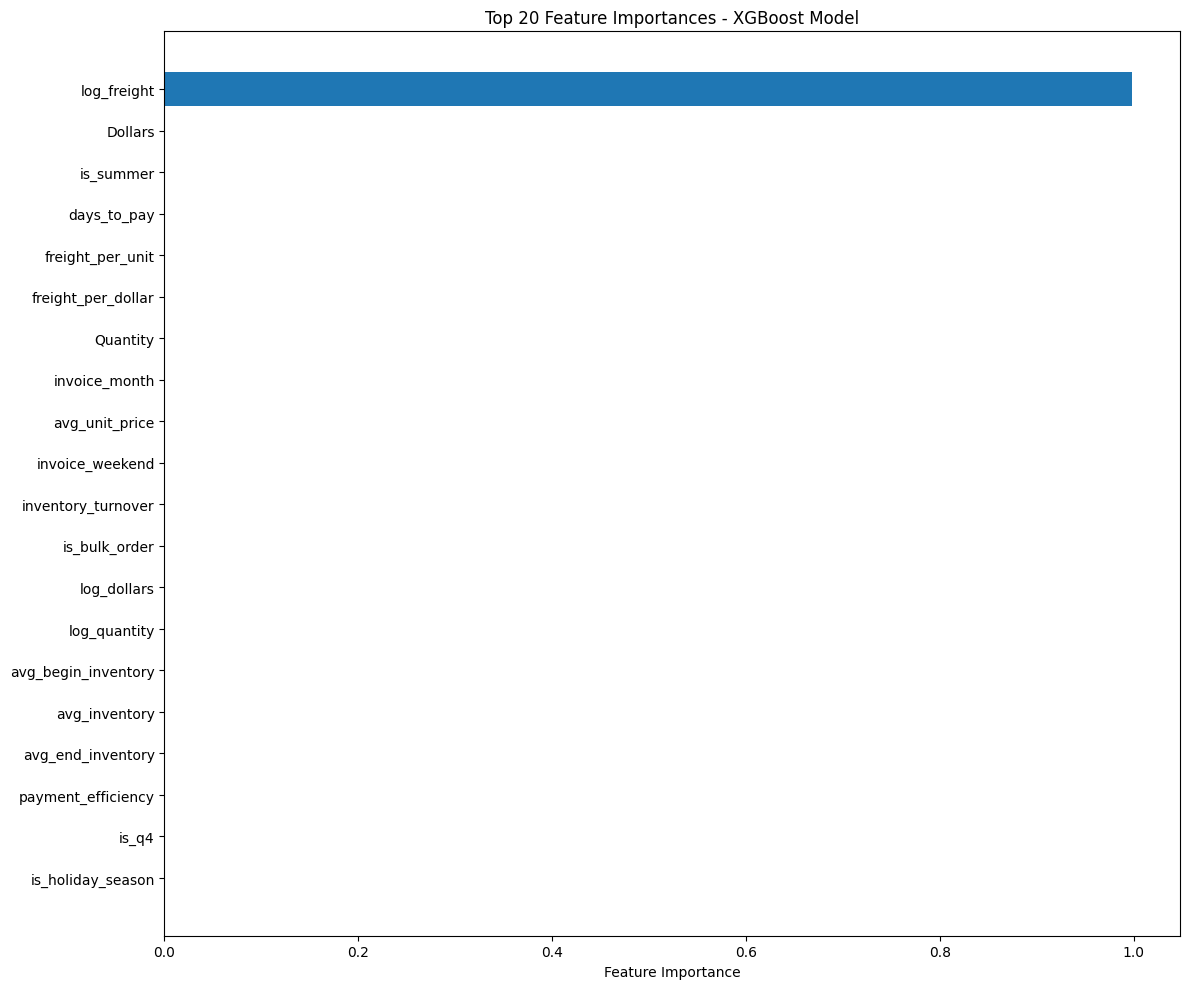


STEP 7: Model Diagnostics


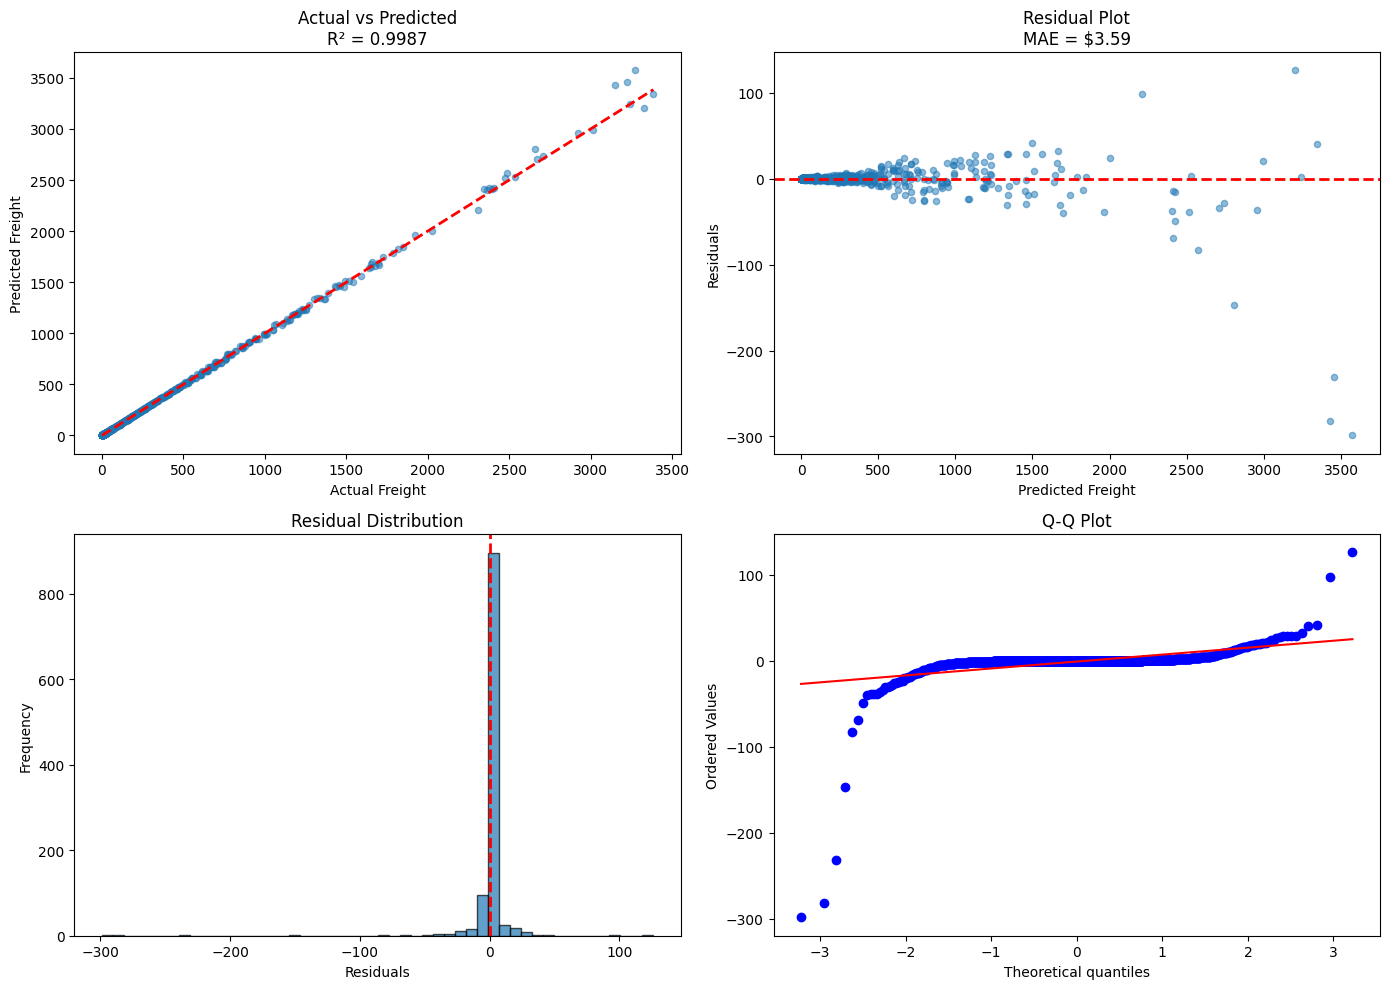


STEP 8: Cross-Validation
5-Fold Cross-Validation R² Scores: [0.99823482 0.99855414 0.99894405 0.99821246 0.9992382 ]
CV Mean R²: 0.9986 (±0.0004)

STEP 9: Saving Model and Artifacts


j:\mlops_revisited\frieght_price_prediction\venv\lib\site-packages\xgboost\sklearn.py:1116: UserWarning: [22:50:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)
Successfully registered model 'xgboost_advanced_features_model'.
2026/03/25 22:51:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: xgboost_advanced_features_model, version 1
Created version '1' of model 'xgboost_advanced_features_model'.



EXPERIMENT COMPLETED SUCCESSFULLY
Run ID: a8884f1eaccf4b2eb28d38a4db1ab394
Experiment: freight_price_prediction_advanced_features

Final Model Performance:
  Test R²: 0.9987
  Test MAE: $3.59
  Test RMSE: $17.30

Top 5 Features:
  log_freight: 0.9980
  Dollars: 0.0005
  is_summer: 0.0003
  days_to_pay: 0.0003
  freight_per_unit: 0.0002



In [19]:
#XGBoost Hyperparameter Tuning
# Define parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

# Reduced grid for faster execution (optional - use this first)
param_grid_reduced = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1]
}

# Start MLflow run
with mlflow.start_run(run_name="XGBoost_Advanced_Features_Tuning") as parent_run:
    
    # Log experiment metadata
    mlflow.log_param("experiment_name", "XGBoost_Advanced_Features")
    mlflow.log_param("total_features", len(selected_features))
    mlflow.log_param("train_samples", len(X_train))
    mlflow.log_param("test_samples", len(X_test))
    mlflow.log_param("feature_list", str(selected_features[:20]))  # Log first 20 features
    
    # Scale features for better performance
    scaler = RobustScaler()  # Robust to outliers
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Log scaler parameters
    mlflow.log_param("scaler_type", "RobustScaler")
    
    # Perform Randomized Search for faster tuning
    print("Starting Randomized Search...")
    start_time = time.time()
    
    xgb = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)
    
    random_search = RandomizedSearchCV(
        xgb,
        param_distributions=param_grid_reduced,
        n_iter=50,  # Number of parameter combinations to try
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    
    random_search.fit(X_train_scaled, y_train)
    
    search_time = time.time() - start_time
    print(f"✓ Randomized Search completed in {search_time:.2f} seconds")
    
    # Get best parameters
    best_params = random_search.best_params_
    best_cv_score = random_search.best_score_
    
    print("\nBest Parameters found:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")
    print(f"Best CV R²: {best_cv_score:.4f}")
    
    # Log best parameters
    mlflow.log_params(best_params)
    mlflow.log_metric("best_cv_r2", best_cv_score)
    
    # ============================================
    # STEP 5: Train Best Model
    # ============================================
    print("\n" + "="*80)
    print("STEP 5: Training Best Model")
    print("="*80)
    
    # Train with best parameters
    best_xgb = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
    best_xgb.fit(X_train_scaled, y_train, 
                 eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
                 verbose=False)
    
    # Make predictions
    y_train_pred = best_xgb.predict(X_train_scaled)
    y_test_pred = best_xgb.predict(X_test_scaled)
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"\n📊 Model Performance:")
    print(f"  Training R²: {train_r2:.4f}")
    print(f"  Training MAE: ${train_mae:.2f}")
    print(f"  Training RMSE: ${train_rmse:.2f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Test MAE: ${test_mae:.2f}")
    print(f"  Test RMSE: ${test_rmse:.2f}")
    print(f"  Overfitting Gap: {train_r2 - test_r2:.4f}")
    
    # Log metrics
    mlflow.log_metrics({
        'train_r2': train_r2,
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'test_r2': test_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'overfitting_gap': train_r2 - test_r2,
        'search_time_seconds': search_time
    })
    
    # ============================================
    # STEP 6: Feature Importance Analysis
    # ============================================
    print("\n" + "="*80)
    print("STEP 6: Feature Importance Analysis")
    print("="*80)
    
    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': selected_features,
        'importance': best_xgb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 20 Most Important Features:")
    print(importance_df.head(20).to_string(index=False))
    
    # Plot feature importance
    fig, ax = plt.subplots(figsize=(12, 10))
    top_features = importance_df.head(20)
    ax.barh(range(len(top_features)), top_features['importance'].values)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'].values)
    ax.set_xlabel('Feature Importance')
    ax.set_title('Top 20 Feature Importances - XGBoost Model')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    mlflow.log_artifact('feature_importance.png')
    plt.show()
    
    # Save importance to CSV
    importance_df.to_csv('feature_importance.csv', index=False)
    mlflow.log_artifact('feature_importance.csv')
    
    # ============================================
    # STEP 7: Model Diagnostics
    # ============================================
    print("\n" + "="*80)
    print("STEP 7: Model Diagnostics")
    print("="*80)
    
    # Create diagnostic plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Actual vs Predicted
    axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, s=20)
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0, 0].set_xlabel('Actual Freight')
    axes[0, 0].set_ylabel('Predicted Freight')
    axes[0, 0].set_title(f'Actual vs Predicted\nR² = {test_r2:.4f}')
    
    # Plot 2: Residuals
    residuals = y_test - y_test_pred
    axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5, s=20)
    axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0, 1].set_xlabel('Predicted Freight')
    axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title(f'Residual Plot\nMAE = ${test_mae:.2f}')
    
    # Plot 3: Residual Distribution
    axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[1, 0].set_xlabel('Residuals')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Residual Distribution')
    
    # Plot 4: Q-Q Plot
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot')
    
    plt.tight_layout()
    plt.savefig('model_diagnostics.png', dpi=150, bbox_inches='tight')
    mlflow.log_artifact('model_diagnostics.png')
    plt.show()
    
    # ============================================
    # STEP 8: Cross-Validation
    # ============================================
    print("\n" + "="*80)
    print("STEP 8: Cross-Validation")
    print("="*80)
    
    cv_scores = cross_val_score(best_xgb, X_train_scaled, y_train, 
                                cv=5, scoring='r2', n_jobs=-1)
    
    print(f"5-Fold Cross-Validation R² Scores: {cv_scores}")
    print(f"CV Mean R²: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    
    mlflow.log_metrics({
        'cv_mean_r2': cv_scores.mean(),
        'cv_std_r2': cv_scores.std()
    })
    
    # ============================================
    # STEP 9: Save Model and Artifacts
    # ============================================
    print("\n" + "="*80)
    print("STEP 9: Saving Model and Artifacts")
    print("="*80)
    
    # Log the model
    mlflow.xgboost.log_model(
        best_xgb,
        "xgboost_advanced_model",
        registered_model_name="xgboost_advanced_features_model"
    )
    
    # Save scaler
    import joblib
    joblib.dump(scaler, 'scaler.pkl')
    mlflow.log_artifact('scaler.pkl')
    
    # Save feature list
    with open('features_used.json', 'w') as f:
        json.dump(selected_features, f, indent=2)
    mlflow.log_artifact('features_used.json')
    
    # Save predictions
    predictions_df = pd.DataFrame({
        'actual': y_test,
        'predicted': y_test_pred,
        'residual': residuals
    })
    predictions_df.to_csv('test_predictions.csv', index=False)
    mlflow.log_artifact('test_predictions.csv')
    
    # Create summary
    summary = {
        'experiment': 'XGBoost_Advanced_Features',
        'total_features': len(selected_features),
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'best_params': best_params,
        'best_cv_r2': float(best_cv_score),
        'test_r2': float(test_r2),
        'test_mae': float(test_mae),
        'test_rmse': float(test_rmse),
        'cv_mean_r2': float(cv_scores.mean()),
        'cv_std_r2': float(cv_scores.std()),
        'timestamp': datetime.now().isoformat()
    }
    
    with open('experiment_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    mlflow.log_artifact('experiment_summary.json')
    
    # ============================================
    # STEP 10: Final Results
    # ============================================
    print("\n" + "="*80)
    print("EXPERIMENT COMPLETED SUCCESSFULLY")
    print("="*80)
    print(f"Run ID: {mlflow.active_run().info.run_id}")
    print(f"Experiment: freight_price_prediction_advanced_features")
    print(f"\nFinal Model Performance:")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Test MAE: ${test_mae:.2f}")
    print(f"  Test RMSE: ${test_rmse:.2f}")
    print(f"\nTop 5 Features:")
    for _, row in importance_df.head(5).iterrows():
        print(f"  {row['feature']}: {row['importance']:.4f}")
    print("\n" + "="*80)
    
    # Return results for comparison
    results = {
        'experiment': 'XGBoost_Advanced_Features',
        'test_r2': test_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'features_used': len(selected_features),
        'best_params': best_params
    }